
# Phase 1 — Exploration des données CIC-IDS2017

Dans cette première phase, l’objectif est d’explorer le dataset CIC-IDS2017 à partir des fichiers CSV,
Cette étape permet de comprendre la structure générale du dataset, la nature des colonnes, les classes présentes, la qualité des données et les problèmes à traiter dans la phase suivante.

---

## Objectifs de la phase d’exploration

Dans cette phase, nous avons cherché à :

- charger les fichiers CSV depuis Google Drive ;
- vérifier l’existence du dossier contenant les données ;
- détecter tous les fichiers CSV disponibles ;
- afficher un aperçu des données avec les premières lignes ;
- connaître le nombre de lignes et de colonnes ;
- afficher les noms des colonnes ;
- vérifier si tous les fichiers CSV possèdent les mêmes colonnes ;
- identifier les types de données : numériques ou textuelles ;
- identifier les classes présentes dans la colonne `Label` ;
- compter le nombre d’exemples par classe ;
- visualiser la distribution des classes ;
- observer le déséquilibre entre trafic normal et attaques ;
- regrouper les classes en deux catégories : `BENIGN` et `ATTACK_or_UNKNOWN` ;
- détecter les valeurs nulles ;
- détecter les valeurs infinies ;
- vérifier la présence de doublons ;
- observer les statistiques descriptives des colonnes numériques ;
- préparer les informations nécessaires pour la phase de nettoyage.

---
## Méthode utilisée

Les fichiers CSV ont d’abord été chargés depuis Google Drive dans Google Colab.

Le dataset étant volumineux, le chargement complet dans un seul DataFrame a provoqué un problème de mémoire RAM. Pour éviter cela, certaines analyses ont été réalisées fichier par fichier ou par morceaux, sans charger tout le dataset en mémoire.

Cette méthode permet de continuer l’exploration de manière plus stable et plus adaptée à un dataset volumineux.




In [3]:
# On importe l'outil Google Drive fourni par Google Colab
from google.colab import drive

# Cette ligne permet de connecter ton Google Drive à Colab
# Après l'exécution, Colab va te demander une autorisation
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# Importer os pour vérifier les dossiers
import os

# Chemin du dossier où se trouvent les fichiers CSV
path = "/content/drive/MyDrive/PFA_/"

# Vérifier si le dossier existe
print(os.path.exists(path))

# Afficher les fichiers dans le dossier
print(os.listdir(path))

True
['Monday-WorkingHours.pcap_ISCX.csv', 'Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv', 'Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv', 'Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv', 'Tuesday-WorkingHours.pcap_ISCX.csv', 'Wednesday-workingHours.pcap_ISCX.csv', 'Friday-WorkingHours-Morning.pcap_ISCX.csv', 'Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv']


In [5]:
# Importer glob pour chercher les fichiers CSV
import glob

# Chercher tous les fichiers qui se terminent par .csv
csv_files = glob.glob(path + "*.csv")

# Afficher le nombre de fichiers CSV trouvés
print("Nombre de fichiers CSV :", len(csv_files))

# Afficher les noms des fichiers trouvés
for file in csv_files:
    print(file)

Nombre de fichiers CSV : 8
/content/drive/MyDrive/PFA_/Monday-WorkingHours.pcap_ISCX.csv
/content/drive/MyDrive/PFA_/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
/content/drive/MyDrive/PFA_/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
/content/drive/MyDrive/PFA_/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
/content/drive/MyDrive/PFA_/Tuesday-WorkingHours.pcap_ISCX.csv
/content/drive/MyDrive/PFA_/Wednesday-workingHours.pcap_ISCX.csv
/content/drive/MyDrive/PFA_/Friday-WorkingHours-Morning.pcap_ISCX.csv
/content/drive/MyDrive/PFA_/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv


In [22]:
# ============================================================
# Aperçu des 5 premières lignes
# Objectif :
# - Observer la forme générale des données
# - Voir un exemple concret de lignes du dataset
# ============================================================

import pandas as pd
import os

# Lire seulement les 5 premières lignes du premier fichier
first_file = csv_files[0]

data_preview = pd.read_csv(first_file, encoding="latin-1", nrows=5)

# Nettoyer uniquement les noms des colonnes
data_preview.columns = data_preview.columns.str.strip()

print("Fichier utilisé pour l'aperçu :", os.path.basename(first_file))

display(data_preview)

Fichier utilisé pour l'aperçu : Monday-WorkingHours.pcap_ISCX.csv


,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,Total Backward Packets,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,192.168.10.5-8.254.250.126-49188-80-6,8.254.250.126,80,192.168.10.5,49188,6,03/07/2017 08:55:58,4,2,0,...,20,0,0,0,0,0,0,0,0,BENIGN
1,192.168.10.5-8.254.250.126-49188-80-6,8.254.250.126,80,192.168.10.5,49188,6,03/07/2017 08:55:58,1,2,0,...,20,0,0,0,0,0,0,0,0,BENIGN
2,192.168.10.5-8.254.250.126-49188-80-6,8.254.250.126,80,192.168.10.5,49188,6,03/07/2017 08:55:58,1,2,0,...,20,0,0,0,0,0,0,0,0,BENIGN
3,192.168.10.5-8.254.250.126-49188-80-6,8.254.250.126,80,192.168.10.5,49188,6,03/07/2017 08:55:58,1,2,0,...,20,0,0,0,0,0,0,0,0,BENIGN
4,192.168.10.14-8.253.185.121-49486-80-6,8.253.185.121,80,192.168.10.14,49486,6,03/07/2017 08:56:22,3,2,0,...,20,0,0,0,0,0,0,0,0,BENIGN


In [23]:
# ============================================================
# Types des données
# Objectif :
# - Voir les types techniques des colonnes
# - Identifier les colonnes numériques
# - Identifier les colonnes textuelles
# ============================================================

import pandas as pd
import os

# Lire un fichier pour vérifier les types
first_file = csv_files[0]

data_types = pd.read_csv(first_file, encoding="latin-1")

# Nettoyer uniquement les noms des colonnes
data_types.columns = data_types.columns.str.strip()

# Résumé des types
print("Résumé des types de données :")
print(data_types.dtypes.value_counts())

print("\nColonnes numériques :")
numeric_cols = data_types.select_dtypes(include=["int64", "float64"]).columns
print("Nombre de colonnes numériques :", len(numeric_cols))
print(list(numeric_cols))

print("\nColonnes textuelles :")
text_cols = data_types.select_dtypes(include=["object"]).columns
print("Nombre de colonnes textuelles :", len(text_cols))
print(list(text_cols))

# Libérer la mémoire
del data_types

Résumé des types de données :
float64    45
int64      35
object      5
Name: count, dtype: int64

Colonnes numériques :
Nombre de colonnes numériques : 80
['Source Port', 'Destination Port', 'Protocol', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Pack

In [6]:
# ============================================================
# Vérification factuelle des valeurs infinies
# Méthode compatible avec notre notebook actuel
# On utilise csv_files déjà créé
# On ne crée pas df complet pour éviter de saturer la RAM
# ============================================================

import pandas as pd
import numpy as np
import os

# Liste pour stocker les résultats
inf_results = []

# Nombre de lignes lues à chaque fois
chunk_size = 100000

# Parcourir les 8 fichiers CSV déjà trouvés
for file in csv_files:
    print("Analyse du fichier :", os.path.basename(file))

    # Lire le fichier par morceaux
    for chunk in pd.read_csv(file, encoding="latin-1", chunksize=chunk_size):

        # Enlever seulement les espaces dans les noms des colonnes
        chunk.columns = chunk.columns.str.strip()

        # Sélectionner les colonnes numériques du morceau
        numeric_cols = chunk.select_dtypes(include=["float64", "int64"]).columns

        # Vérifier les valeurs infinies dans chaque colonne numérique
        for col in numeric_cols:
            nombre_inf = np.isinf(chunk[col]).sum()

            if nombre_inf > 0:
                inf_results.append({
                    "fichier": os.path.basename(file),
                    "colonne": col,
                    "nombre_valeurs_infinies": nombre_inf
                })

# Créer le tableau final
inf_table = pd.DataFrame(inf_results)

# Si on a trouvé des valeurs infinies, on regroupe les résultats
if len(inf_table) > 0:
    inf_table = inf_table.groupby(
        ["fichier", "colonne"],
        as_index=False
    )["nombre_valeurs_infinies"].sum()

display(inf_table)

print("Vérification terminée.")

Analyse du fichier : Monday-WorkingHours.pcap_ISCX.csv
Analyse du fichier : Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv


/tmp/ipykernel_29282/4183554294.py:23: DtypeWarning: Columns (0,1,3,6,84) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(file, encoding="latin-1", chunksize=chunk_size):


Analyse du fichier : Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Analyse du fichier : Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Analyse du fichier : Tuesday-WorkingHours.pcap_ISCX.csv
Analyse du fichier : Wednesday-workingHours.pcap_ISCX.csv
Analyse du fichier : Friday-WorkingHours-Morning.pcap_ISCX.csv
Analyse du fichier : Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv


,fichier,colonne,nombre_valeurs_infinies
0,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv,Flow Bytes/s,30
1,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv,Flow Packets/s,34
2,Friday-WorkingHours-Afternoon-PortScan.pcap_IS...,Flow Bytes/s,356
3,Friday-WorkingHours-Afternoon-PortScan.pcap_IS...,Flow Packets/s,371
4,Friday-WorkingHours-Morning.pcap_ISCX.csv,Flow Bytes/s,94
5,Friday-WorkingHours-Morning.pcap_ISCX.csv,Flow Packets/s,122
6,Monday-WorkingHours.pcap_ISCX.csv,Flow Bytes/s,373
7,Monday-WorkingHours.pcap_ISCX.csv,Flow Packets/s,437
8,Thursday-WorkingHours-Afternoon-Infilteration....,Flow Bytes/s,189
9,Thursday-WorkingHours-Afternoon-Infilteration....,Flow Packets/s,207


Vérification terminée.


La vérification factuelle des valeurs infinies montre que certaines valeurs +inf ou -inf existent dans le dataset. Elles apparaissent uniquement dans les colonnes Flow Bytes/s et Flow Packets/s. Aucune correction n’est effectuée à cette étape, mais ces valeurs devront être traitées pendant la phase de nettoyage.

In [7]:
# ============================================================
# Vérification des doublons fichier par fichier
# Objectif :
# - Voir si chaque CSV contient des lignes dupliquées
# - Ne rien supprimer
# - Éviter de charger tout le dataset en mémoire
# ============================================================

import pandas as pd
import os

doublons_results = []

for file in csv_files:
    print("Analyse du fichier :", os.path.basename(file))

    # Lire un fichier à la fois
    data = pd.read_csv(file, encoding="latin-1")

    # Nettoyer seulement les noms de colonnes
    data.columns = data.columns.str.strip()

    # Nombre total de lignes
    total_lignes = len(data)

    # Nombre de lignes dupliquées
    nb_doublons = data.duplicated().sum()

    # Pourcentage de doublons
    pourcentage = (nb_doublons / total_lignes) * 100

    doublons_results.append({
        "fichier": os.path.basename(file),
        "nombre_lignes": total_lignes,
        "nombre_doublons": nb_doublons,
        "pourcentage_doublons": round(pourcentage, 2)
    })

    # Libérer la variable après chaque fichier
    del data

doublons_table = pd.DataFrame(doublons_results)

display(doublons_table)

Analyse du fichier : Monday-WorkingHours.pcap_ISCX.csv
Analyse du fichier : Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv


/tmp/ipykernel_29282/3597457477.py:18: DtypeWarning: Columns (0,1,3,6,84) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(file, encoding="latin-1")


Analyse du fichier : Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Analyse du fichier : Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Analyse du fichier : Tuesday-WorkingHours.pcap_ISCX.csv
Analyse du fichier : Wednesday-workingHours.pcap_ISCX.csv
Analyse du fichier : Friday-WorkingHours-Morning.pcap_ISCX.csv
Analyse du fichier : Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv


,fichier,nombre_lignes,nombre_doublons,pourcentage_doublons
0,Monday-WorkingHours.pcap_ISCX.csv,529918,34,0.01
1,Thursday-WorkingHours-Morning-WebAttacks.pcap_...,458968,288602,62.88
2,Friday-WorkingHours-Afternoon-PortScan.pcap_IS...,286467,1,0.00
3,Thursday-WorkingHours-Afternoon-Infilteration....,288602,142,0.05
4,Tuesday-WorkingHours.pcap_ISCX.csv,445909,4,0.00
5,Wednesday-workingHours.pcap_ISCX.csv,692703,17,0.00
6,Friday-WorkingHours-Morning.pcap_ISCX.csv,191033,2,0.00
7,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv,225745,2,0.00


In [12]:
# ============================================================
# Afficher les noms des colonnes
# Objectif :
# - Voir quelles sont les colonnes du dataset
# - Vérifier la structure sans charger toutes les lignes
# ============================================================

# Lire uniquement l'en-tête du premier fichier CSV
first_file = csv_files[0]

data_header = pd.read_csv(first_file, encoding="latin-1", nrows=0)

# Nettoyer seulement les noms des colonnes
columns = data_header.columns.str.strip()

print("Nombre de colonnes :", len(columns))

print("\nListe des colonnes :")
for col in columns:
    print(col)

Nombre de colonnes : 85

Liste des colonnes :
Flow ID
Source IP
Source Port
Destination IP
Destination Port
Protocol
Timestamp
Flow Duration
Total Fwd Packets
Total Backward Packets
Total Length of Fwd Packets
Total Length of Bwd Packets
Fwd Packet Length Max
Fwd Packet Length Min
Fwd Packet Length Mean
Fwd Packet Length Std
Bwd Packet Length Max
Bwd Packet Length Min
Bwd Packet Length Mean
Bwd Packet Length Std
Flow Bytes/s
Flow Packets/s
Flow IAT Mean
Flow IAT Std
Flow IAT Max
Flow IAT Min
Fwd IAT Total
Fwd IAT Mean
Fwd IAT Std
Fwd IAT Max
Fwd IAT Min
Bwd IAT Total
Bwd IAT Mean
Bwd IAT Std
Bwd IAT Max
Bwd IAT Min
Fwd PSH Flags
Bwd PSH Flags
Fwd URG Flags
Bwd URG Flags
Fwd Header Length
Bwd Header Length
Fwd Packets/s
Bwd Packets/s
Min Packet Length
Max Packet Length
Packet Length Mean
Packet Length Std
Packet Length Variance
FIN Flag Count
SYN Flag Count
RST Flag Count
PSH Flag Count
ACK Flag Count
URG Flag Count
CWE Flag Count
ECE Flag Count
Down/Up Ratio
Average Packet Size
Avg Fwd

In [13]:
# ============================================================
# Vérifier si tous les fichiers CSV ont les mêmes colonnes
# Objectif :
# - Comparer les colonnes de chaque fichier
# - Vérifier que la structure est cohérente
# ============================================================

# Colonnes du premier fichier comme référence
reference_columns = pd.read_csv(csv_files[0], encoding="latin-1", nrows=0).columns.str.strip().tolist()

for file in csv_files:

    current_columns = pd.read_csv(file, encoding="latin-1", nrows=0).columns.str.strip().tolist()

    if current_columns == reference_columns:
        print(os.path.basename(file), ": mêmes colonnes")
    else:
        print(os.path.basename(file), ": colonnes différentes")

Monday-WorkingHours.pcap_ISCX.csv : mêmes colonnes
Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv : mêmes colonnes
Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv : mêmes colonnes
Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv : mêmes colonnes
Tuesday-WorkingHours.pcap_ISCX.csv : mêmes colonnes
Wednesday-workingHours.pcap_ISCX.csv : mêmes colonnes
Friday-WorkingHours-Morning.pcap_ISCX.csv : mêmes colonnes
Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv : mêmes colonnes


In [14]:
# ============================================================
# Classes / Labels du dataset CIC-IDS2017
# Objectif :
# - Afficher toutes les classes présentes dans la colonne Label
# - Compter combien de lignes il y a pour chaque classe
# - Lire les fichiers un par un pour éviter de saturer la RAM
# ============================================================

import pandas as pd
import os

labels_results = []

for file in csv_files:
    print("Analyse du fichier :", os.path.basename(file))

    # Lire uniquement la colonne Label
    data = pd.read_csv(file, encoding="latin-1", usecols=lambda col: col.strip() == "Label")

    # Nettoyer le nom de la colonne
    data.columns = data.columns.str.strip()

    # Compter les labels dans ce fichier
    counts = data["Label"].value_counts(dropna=False)

    for label, count in counts.items():
        labels_results.append({
            "Label": label,
            "nombre_lignes": count
        })

# Créer un tableau
labels_table = pd.DataFrame(labels_results)

# Regrouper les résultats de tous les fichiers
labels_table = labels_table.groupby("Label", dropna=False, as_index=False)["nombre_lignes"].sum()

# Trier du plus fréquent au moins fréquent
labels_table = labels_table.sort_values(by="nombre_lignes", ascending=False)

display(labels_table)

print("Nombre total de classes avec NaN inclus :", labels_table.shape[0])
print("Nombre total de lignes comptées :", labels_table["nombre_lignes"].sum())

Analyse du fichier : Monday-WorkingHours.pcap_ISCX.csv
Analyse du fichier : Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv


/tmp/ipykernel_29282/32834630.py:18: DtypeWarning: Columns (84) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(file, encoding="latin-1", usecols=lambda col: col.strip() == "Label")


Analyse du fichier : Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Analyse du fichier : Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Analyse du fichier : Tuesday-WorkingHours.pcap_ISCX.csv
Analyse du fichier : Wednesday-workingHours.pcap_ISCX.csv
Analyse du fichier : Friday-WorkingHours-Morning.pcap_ISCX.csv
Analyse du fichier : Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv


,Label,nombre_lignes
0,BENIGN,2273097
15,NaN,288602
4,DoS Hulk,231073
10,PortScan,158930
2,DDoS,128027
3,DoS GoldenEye,10293
7,FTP-Patator,7938
11,SSH-Patator,5897
6,DoS slowloris,5796
5,DoS Slowhttptest,5499


Nombre total de classes avec NaN inclus : 16
Nombre total de lignes comptées : 3119345


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 150 (\x96) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


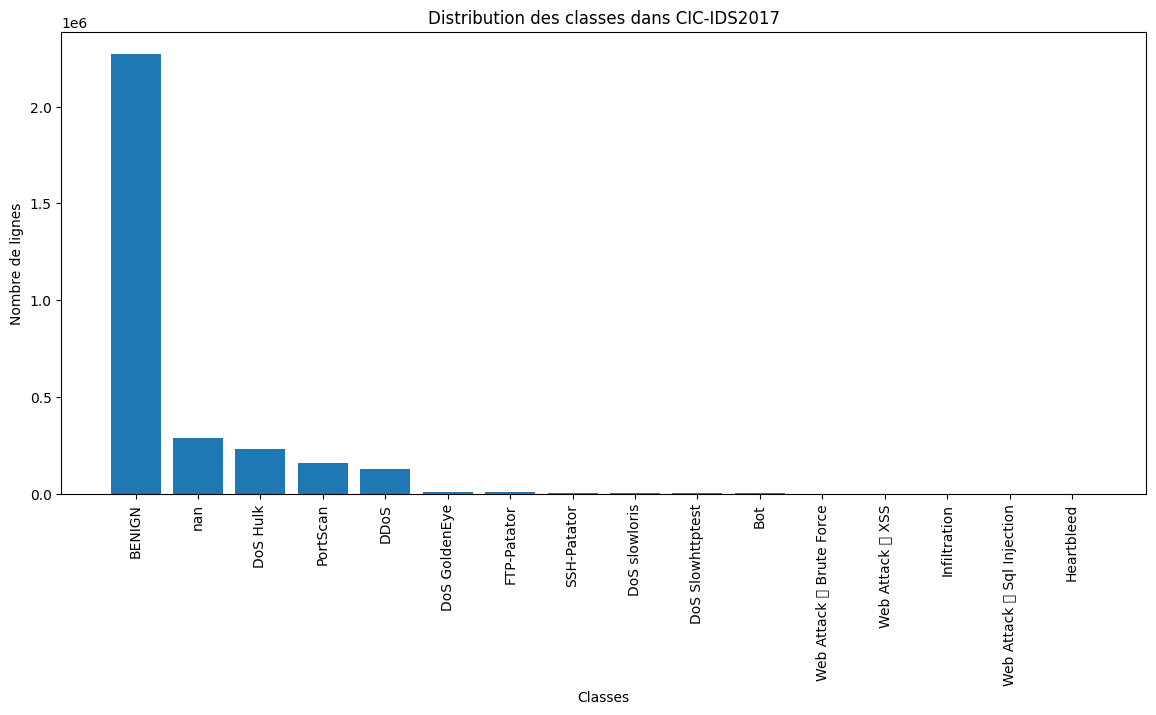

In [15]:
# ============================================================
# Visualisation de la distribution des classes
# Objectif :
# - Voir quelles classes sont majoritaires
# - Voir quelles classes sont rares
# - Ne rien modifier dans les données
# ============================================================

import matplotlib.pyplot as plt

# Copier le tableau des labels
labels_plot = labels_table.copy()

# Convertir les labels en texte pour l'affichage
labels_plot["Label"] = labels_plot["Label"].astype(str)

# Créer le graphique
plt.figure(figsize=(14, 6))
plt.bar(labels_plot["Label"], labels_plot["nombre_lignes"])

plt.title("Distribution des classes dans CIC-IDS2017")
plt.xlabel("Classes")
plt.ylabel("Nombre de lignes")
plt.xticks(rotation=90)

plt.show()

In [17]:
# ============================================================
# Valeurs nulles par fichier
# Objectif :
# - Compter les valeurs nulles dans chaque fichier CSV
# - Ne rien supprimer
# - Ne pas charger tout le dataset en RAM
# ============================================================

import pandas as pd
import os

nulls_results = []

for file in csv_files:
    print("Analyse du fichier :", os.path.basename(file))

    data = pd.read_csv(file, encoding="latin-1")
    data.columns = data.columns.str.strip()

    total_nulls = data.isna().sum().sum()

    nulls_results.append({
        "fichier": os.path.basename(file),
        "nombre_lignes": len(data),
        "nombre_colonnes": data.shape[1],
        "total_valeurs_nulles": total_nulls
    })

    del data

nulls_table = pd.DataFrame(nulls_results)

display(nulls_table)

Analyse du fichier : Monday-WorkingHours.pcap_ISCX.csv
Analyse du fichier : Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv


/tmp/ipykernel_29282/1960150014.py:17: DtypeWarning: Columns (0,1,3,6,84) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(file, encoding="latin-1")


Analyse du fichier : Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Analyse du fichier : Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Analyse du fichier : Tuesday-WorkingHours.pcap_ISCX.csv
Analyse du fichier : Wednesday-workingHours.pcap_ISCX.csv
Analyse du fichier : Friday-WorkingHours-Morning.pcap_ISCX.csv
Analyse du fichier : Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv


,fichier,nombre_lignes,nombre_colonnes,total_valeurs_nulles
0,Monday-WorkingHours.pcap_ISCX.csv,529918,85,64
1,Thursday-WorkingHours-Morning-WebAttacks.pcap_...,458968,85,24531190
2,Friday-WorkingHours-Afternoon-PortScan.pcap_IS...,286467,85,15
3,Thursday-WorkingHours-Afternoon-Infilteration....,288602,85,18
4,Tuesday-WorkingHours.pcap_ISCX.csv,445909,85,201
5,Wednesday-workingHours.pcap_ISCX.csv,692703,85,1008
6,Friday-WorkingHours-Morning.pcap_ISCX.csv,191033,85,28
7,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv,225745,85,4


Les valeurs nulles sont principalement concentrées dans le fichier WebAttacks.
Les autres fichiers contiennent seulement quelques valeurs nulles isolées.

In [18]:
# ============================================================
# Statistiques descriptives par fichier
# Objectif :
# - Observer les colonnes numériques
# - Voir les min, max, moyenne, écart-type
# - Ne rien modifier dans les données
# ============================================================

import pandas as pd
import os

for file in csv_files:
    print("\n==============================================")
    print("Statistiques du fichier :", os.path.basename(file))
    print("==============================================")

    # Lire un fichier à la fois
    data = pd.read_csv(file, encoding="latin-1")

    # Nettoyer uniquement les noms des colonnes
    data.columns = data.columns.str.strip()

    # Sélectionner les colonnes numériques
    numeric_data = data.select_dtypes(include=["float64", "int64"])

    # Afficher les statistiques descriptives
    display(numeric_data.describe().T[["count", "mean", "std", "min", "max"]])

    # Libérer la mémoire
    del data


Statistiques du fichier : Monday-WorkingHours.pcap_ISCX.csv


,count,mean,std,min,max
Source Port,529918.0,4.032859e+04,2.439153e+04,0.0,6.553500e+04
Destination Port,529918.0,1.064437e+04,2.139021e+04,0.0,6.553500e+04
Protocol,529918.0,1.064988e+01,5.439519e+00,0.0,1.700000e+01
Flow Duration,529918.0,1.038927e+07,2.875195e+07,-1.0,1.200000e+08
Total Fwd Packets,529918.0,1.039032e+01,8.924128e+02,1.0,2.197590e+05
...,...,...,...,...,...
Active Min,529918.0,4.380369e+04,4.993677e+05,0.0,1.016597e+08
Idle Mean,529918.0,3.463918e+06,1.297057e+07,0.0,1.199997e+08
Idle Std,529918.0,2.024408e+05,2.170149e+06,0.0,7.514502e+07
Idle Max,529918.0,3.620657e+06,1.340649e+07,0.0,1.199997e+08



Statistiques du fichier : Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv


/tmp/ipykernel_29282/2140339865.py:18: DtypeWarning: Columns (0,1,3,6,84) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(file, encoding="latin-1")


,count,mean,std,min,max
Source Port,170366.0,4.016057e+04,2.384447e+04,0.0,65534.0
Destination Port,170366.0,7.897091e+03,1.823549e+04,0.0,65529.0
Protocol,170366.0,1.127467e+01,5.503074e+00,0.0,17.0
Flow Duration,170366.0,1.246354e+07,3.193852e+07,-1.0,119999993.0
Total Fwd Packets,170366.0,1.512462e+01,1.123108e+03,1.0,200755.0
...,...,...,...,...,...
Active Min,170366.0,5.012699e+04,5.606797e+05,0.0,103000000.0
Idle Mean,170366.0,3.690478e+06,1.298830e+07,0.0,120000000.0
Idle Std,170366.0,1.310724e+05,1.733767e+06,0.0,72600000.0
Idle Max,170366.0,3.784764e+06,1.325135e+07,0.0,120000000.0


...

,count,mean,std,min,max
Source Port,692703.0,4.258400e+04,1.953570e+04,0.0,65535.0
Destination Port,692703.0,5.686869e+03,1.572742e+04,0.0,65487.0
Protocol,692703.0,9.219523e+00,5.009796e+00,0.0,17.0
Flow Duration,692703.0,2.800168e+07,4.276680e+07,-1.0,119999998.0
Total Fwd Packets,692703.0,9.556261e+00,7.471978e+02,1.0,203943.0
...,...,...,...,...,...
Active Min,692703.0,6.315186e+04,6.051023e+05,0.0,100000000.0
Idle Mean,692703.0,2.211122e+07,3.812415e+07,0.0,120000000.0
Idle Std,692703.0,4.743744e+05,4.488512e+06,0.0,76900000.0
Idle Max,692703.0,2.252174e+07,3.848292e+07,0.0,120000000.0



Statistiques du fichier : Friday-WorkingHours-Morning.pcap_ISCX.csv


,count,mean,std,min,max
Source Port,191033.0,3.848543e+04,2.422565e+04,0.0,65535.0
Destination Port,191033.0,6.756070e+03,1.669744e+04,0.0,64948.0
Protocol,191033.0,1.150476e+01,5.507385e+00,0.0,17.0
Flow Duration,191033.0,1.164499e+07,3.070084e+07,-12.0,119999993.0
Total Fwd Packets,191033.0,1.382655e+01,1.097756e+03,1.0,207964.0
...,...,...,...,...,...
Active Min,191033.0,5.589691e+04,7.628561e+05,0.0,106000000.0
Idle Mean,191033.0,3.917041e+06,1.388267e+07,0.0,120000000.0
Idle Std,191033.0,1.750674e+05,2.167443e+06,0.0,76600000.0
Idle Max,191033.0,4.048164e+06,1.424123e+07,0.0,120000000.0



Statistiques du fichier : Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv


,count,mean,std,min,max
Source Port,225745.0,3.825757e+04,2.305730e+04,0.0,65534.0
Destination Port,225745.0,8.879619e+03,1.975465e+04,0.0,65532.0
Protocol,225745.0,7.600288e+00,3.881586e+00,0.0,17.0
Flow Duration,225745.0,1.624165e+07,3.152437e+07,-1.0,119999937.0
Total Fwd Packets,225745.0,4.874916e+00,1.542287e+01,1.0,1932.0
...,...,...,...,...,...
Active Min,225745.0,1.776201e+05,7.842602e+05,0.0,100000000.0
Idle Mean,225745.0,1.032214e+07,2.185303e+07,0.0,120000000.0
Idle Std,225745.0,3.611943e+06,1.275689e+07,0.0,65300000.0
Idle Max,225745.0,1.287813e+07,2.692126e+07,0.0,120000000.0


In [19]:
# ============================================================
# Statistiques descriptives des colonnes numériques par fichier
# Objectif :
# - Observer les valeurs min, max, moyenne, écart-type
# - Détecter visuellement des valeurs extrêmes
# - Ne rien modifier dans les données
# ============================================================

import pandas as pd
import os

for file in csv_files:
    print("\n====================================================")
    print("Fichier :", os.path.basename(file))
    print("====================================================")

    # Lire un fichier à la fois pour éviter de saturer la RAM
    data = pd.read_csv(file, encoding="latin-1")

    # Nettoyer uniquement les noms des colonnes
    data.columns = data.columns.str.strip()

    # Sélectionner seulement les colonnes numériques
    numeric_data = data.select_dtypes(include=["float64", "int64"])

    # Afficher les statistiques principales
    stats = numeric_data.describe().T[["count", "mean", "std", "min", "max"]]

    display(stats)

    # Libérer la mémoire
    del data


Fichier : Monday-WorkingHours.pcap_ISCX.csv


,count,mean,std,min,max
Source Port,529918.0,4.032859e+04,2.439153e+04,0.0,6.553500e+04
Destination Port,529918.0,1.064437e+04,2.139021e+04,0.0,6.553500e+04
Protocol,529918.0,1.064988e+01,5.439519e+00,0.0,1.700000e+01
Flow Duration,529918.0,1.038927e+07,2.875195e+07,-1.0,1.200000e+08
Total Fwd Packets,529918.0,1.039032e+01,8.924128e+02,1.0,2.197590e+05
...,...,...,...,...,...
Active Min,529918.0,4.380369e+04,4.993677e+05,0.0,1.016597e+08
Idle Mean,529918.0,3.463918e+06,1.297057e+07,0.0,1.199997e+08
Idle Std,529918.0,2.024408e+05,2.170149e+06,0.0,7.514502e+07
Idle Max,529918.0,3.620657e+06,1.340649e+07,0.0,1.199997e+08



Fichier : Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv


/tmp/ipykernel_29282/1954939554.py:18: DtypeWarning: Columns (0,1,3,6,84) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(file, encoding="latin-1")


,count,mean,std,min,max
Source Port,170366.0,4.016057e+04,2.384447e+04,0.0,65534.0
Destination Port,170366.0,7.897091e+03,1.823549e+04,0.0,65529.0
Protocol,170366.0,1.127467e+01,5.503074e+00,0.0,17.0
Flow Duration,170366.0,1.246354e+07,3.193852e+07,-1.0,119999993.0
Total Fwd Packets,170366.0,1.512462e+01,1.123108e+03,1.0,200755.0
...,...,...,...,...,...
Active Min,170366.0,5.012699e+04,5.606797e+05,0.0,103000000.0
Idle Mean,170366.0,3.690478e+06,1.298830e+07,0.0,120000000.0
Idle Std,170366.0,1.310724e+05,1.733767e+06,0.0,72600000.0
Idle Max,170366.0,3.784764e+06,1.325135e+07,0.0,120000000.0


...

,count,mean,std,min,max
Source Port,692703.0,4.258400e+04,1.953570e+04,0.0,65535.0
Destination Port,692703.0,5.686869e+03,1.572742e+04,0.0,65487.0
Protocol,692703.0,9.219523e+00,5.009796e+00,0.0,17.0
Flow Duration,692703.0,2.800168e+07,4.276680e+07,-1.0,119999998.0
Total Fwd Packets,692703.0,9.556261e+00,7.471978e+02,1.0,203943.0
...,...,...,...,...,...
Active Min,692703.0,6.315186e+04,6.051023e+05,0.0,100000000.0
Idle Mean,692703.0,2.211122e+07,3.812415e+07,0.0,120000000.0
Idle Std,692703.0,4.743744e+05,4.488512e+06,0.0,76900000.0
Idle Max,692703.0,2.252174e+07,3.848292e+07,0.0,120000000.0



Fichier : Friday-WorkingHours-Morning.pcap_ISCX.csv


,count,mean,std,min,max
Source Port,191033.0,3.848543e+04,2.422565e+04,0.0,65535.0
Destination Port,191033.0,6.756070e+03,1.669744e+04,0.0,64948.0
Protocol,191033.0,1.150476e+01,5.507385e+00,0.0,17.0
Flow Duration,191033.0,1.164499e+07,3.070084e+07,-12.0,119999993.0
Total Fwd Packets,191033.0,1.382655e+01,1.097756e+03,1.0,207964.0
...,...,...,...,...,...
Active Min,191033.0,5.589691e+04,7.628561e+05,0.0,106000000.0
Idle Mean,191033.0,3.917041e+06,1.388267e+07,0.0,120000000.0
Idle Std,191033.0,1.750674e+05,2.167443e+06,0.0,76600000.0
Idle Max,191033.0,4.048164e+06,1.424123e+07,0.0,120000000.0



Fichier : Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv


,count,mean,std,min,max
Source Port,225745.0,3.825757e+04,2.305730e+04,0.0,65534.0
Destination Port,225745.0,8.879619e+03,1.975465e+04,0.0,65532.0
Protocol,225745.0,7.600288e+00,3.881586e+00,0.0,17.0
Flow Duration,225745.0,1.624165e+07,3.152437e+07,-1.0,119999937.0
Total Fwd Packets,225745.0,4.874916e+00,1.542287e+01,1.0,1932.0
...,...,...,...,...,...
Active Min,225745.0,1.776201e+05,7.842602e+05,0.0,100000000.0
Idle Mean,225745.0,1.032214e+07,2.185303e+07,0.0,120000000.0
Idle Std,225745.0,3.611943e+06,1.275689e+07,0.0,65300000.0
Idle Max,225745.0,1.287813e+07,2.692126e+07,0.0,120000000.0


In [20]:
# ============================================================
# Répartition trafic normal / attaques
# Objectif :
# - Regrouper les labels en deux catégories : BENIGN et ATTACK
# - Voir la proportion de trafic normal et de trafic malveillant
# - Ne rien modifier dans les données
# ============================================================

import pandas as pd

# Copier le tableau des labels déjà créé
binary_table = labels_table.copy()

# Remplacer NaN par "NaN" pour l'affichage
binary_table["Label"] = binary_table["Label"].astype(str)

# Créer une nouvelle catégorie
binary_table["categorie"] = binary_table["Label"].apply(
    lambda x: "BENIGN" if x == "BENIGN" else "ATTACK_or_UNKNOWN"
)

# Regrouper par catégorie
binary_distribution = binary_table.groupby("categorie", as_index=False)["nombre_lignes"].sum()

# Calculer le pourcentage
total = binary_distribution["nombre_lignes"].sum()
binary_distribution["pourcentage"] = (binary_distribution["nombre_lignes"] / total * 100).round(2)

display(binary_distribution)

,categorie,nombre_lignes,pourcentage
0,ATTACK_or_UNKNOWN,846248,27.13
1,BENIGN,2273097,72.87


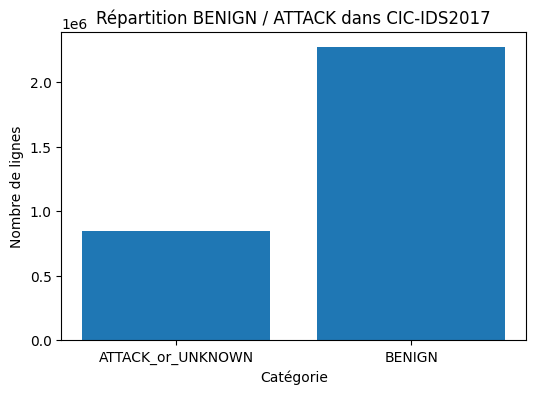

In [21]:
# ============================================================
# Graphique trafic normal / attaques
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.bar(binary_distribution["categorie"], binary_distribution["nombre_lignes"])

plt.title("Répartition BENIGN / ATTACK dans CIC-IDS2017")
plt.xlabel("Catégorie")
plt.ylabel("Nombre de lignes")

plt.show()